# 📊 Notebook 07 — Model Comparison & Final Analysis

**Load all saved metrics and produce:**
1. Comparison table (MAE, RMSE, MAPE, R²)
2. Bar chart comparison
3. Training curves overlay
4. Prediction vs Ground Truth overlay for all DL models
5. Parameters vs accuracy scatter

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import glob

plt.rcParams.update({
    'figure.dpi'      : 150,
    'font.family'     : 'DejaVu Sans',
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

RESULTS_DIR = '../results'
print('✅ Imports OK')

✅ Imports OK


## 1. Load All Saved Metrics

In [2]:
METRICS_FILES = {
    'LSTM (Scratch)'             : '../results/lstm_metrics.pkl',
    'GRU (Scratch)'              : '../results/gru_metrics.pkl',
    'STFormer (Scratch)'         : '../results/stformer_metrics.pkl',
    'Random Forest (Library)'    : '../results/rf_metrics.pkl',
    'XGBoost (Library)'          : '../results/xgb_metrics.pkl',
    'Transformer (Library)'      : '../results/transformer_lib_metrics.pkl',
}

all_metrics  = {}
all_data     = {}
missing      = []

for name, path in METRICS_FILES.items():
    if os.path.exists(path):
        with open(path, 'rb') as f:
            d = pickle.load(f)
        all_metrics[name] = d['metrics']
        all_data[name]    = d
        print(f'✅ Loaded: {name}')
    else:
        missing.append(name)
        print(f'⚠️  Missing: {name} — run its notebook first')

print(f'\nLoaded {len(all_metrics)} / {len(METRICS_FILES)} models')

✅ Loaded: LSTM (Scratch)
✅ Loaded: GRU (Scratch)
✅ Loaded: STFormer (Scratch)
✅ Loaded: Random Forest (Library)
✅ Loaded: XGBoost (Library)
✅ Loaded: Transformer (Library)

Loaded 6 / 6 models


## 2. Comparison Table

In [3]:
rows = []
for name, m in all_metrics.items():
    impl_type = 'From Scratch' if 'Scratch' in name else 'Library'
    rows.append({
        'Model'       : name,
        'Type'        : impl_type,
        'MAE ↓'       : round(m['MAE'],  4),
        'RMSE ↓'      : round(m['RMSE'], 4),
        'MAPE (%) ↓'  : round(m['MAPE'], 2),
        'R² ↑'        : round(m['R2'],   4),
    })

df_results = pd.DataFrame(rows).set_index('Model')
# Sort by MAE ascending (lower is better)
df_results = df_results.sort_values('MAE ↓')

print(df_results.to_string())

# Save as CSV
df_results.to_csv('../results/model_comparison.csv')
print('\n✅ Saved → results/model_comparison.csv')

                                 Type   MAE ↓   RMSE ↓  MAPE (%) ↓    R² ↑
Model                                                                     
XGBoost (Library)             Library  3.4378   7.3865        6.63  0.8949
STFormer (Scratch)       From Scratch  4.5524   8.6533        9.28  0.8557
Transformer (Library)         Library  4.8293   9.6216       10.34  0.8216
GRU (Scratch)            From Scratch  4.9858   9.8460       10.30  0.8132
LSTM (Scratch)           From Scratch  5.0774   9.9424       10.28  0.8096
Random Forest (Library)       Library  5.7742  11.1871       12.33  0.7589

✅ Saved → results/model_comparison.csv


## 3. Bar Chart — All Metrics

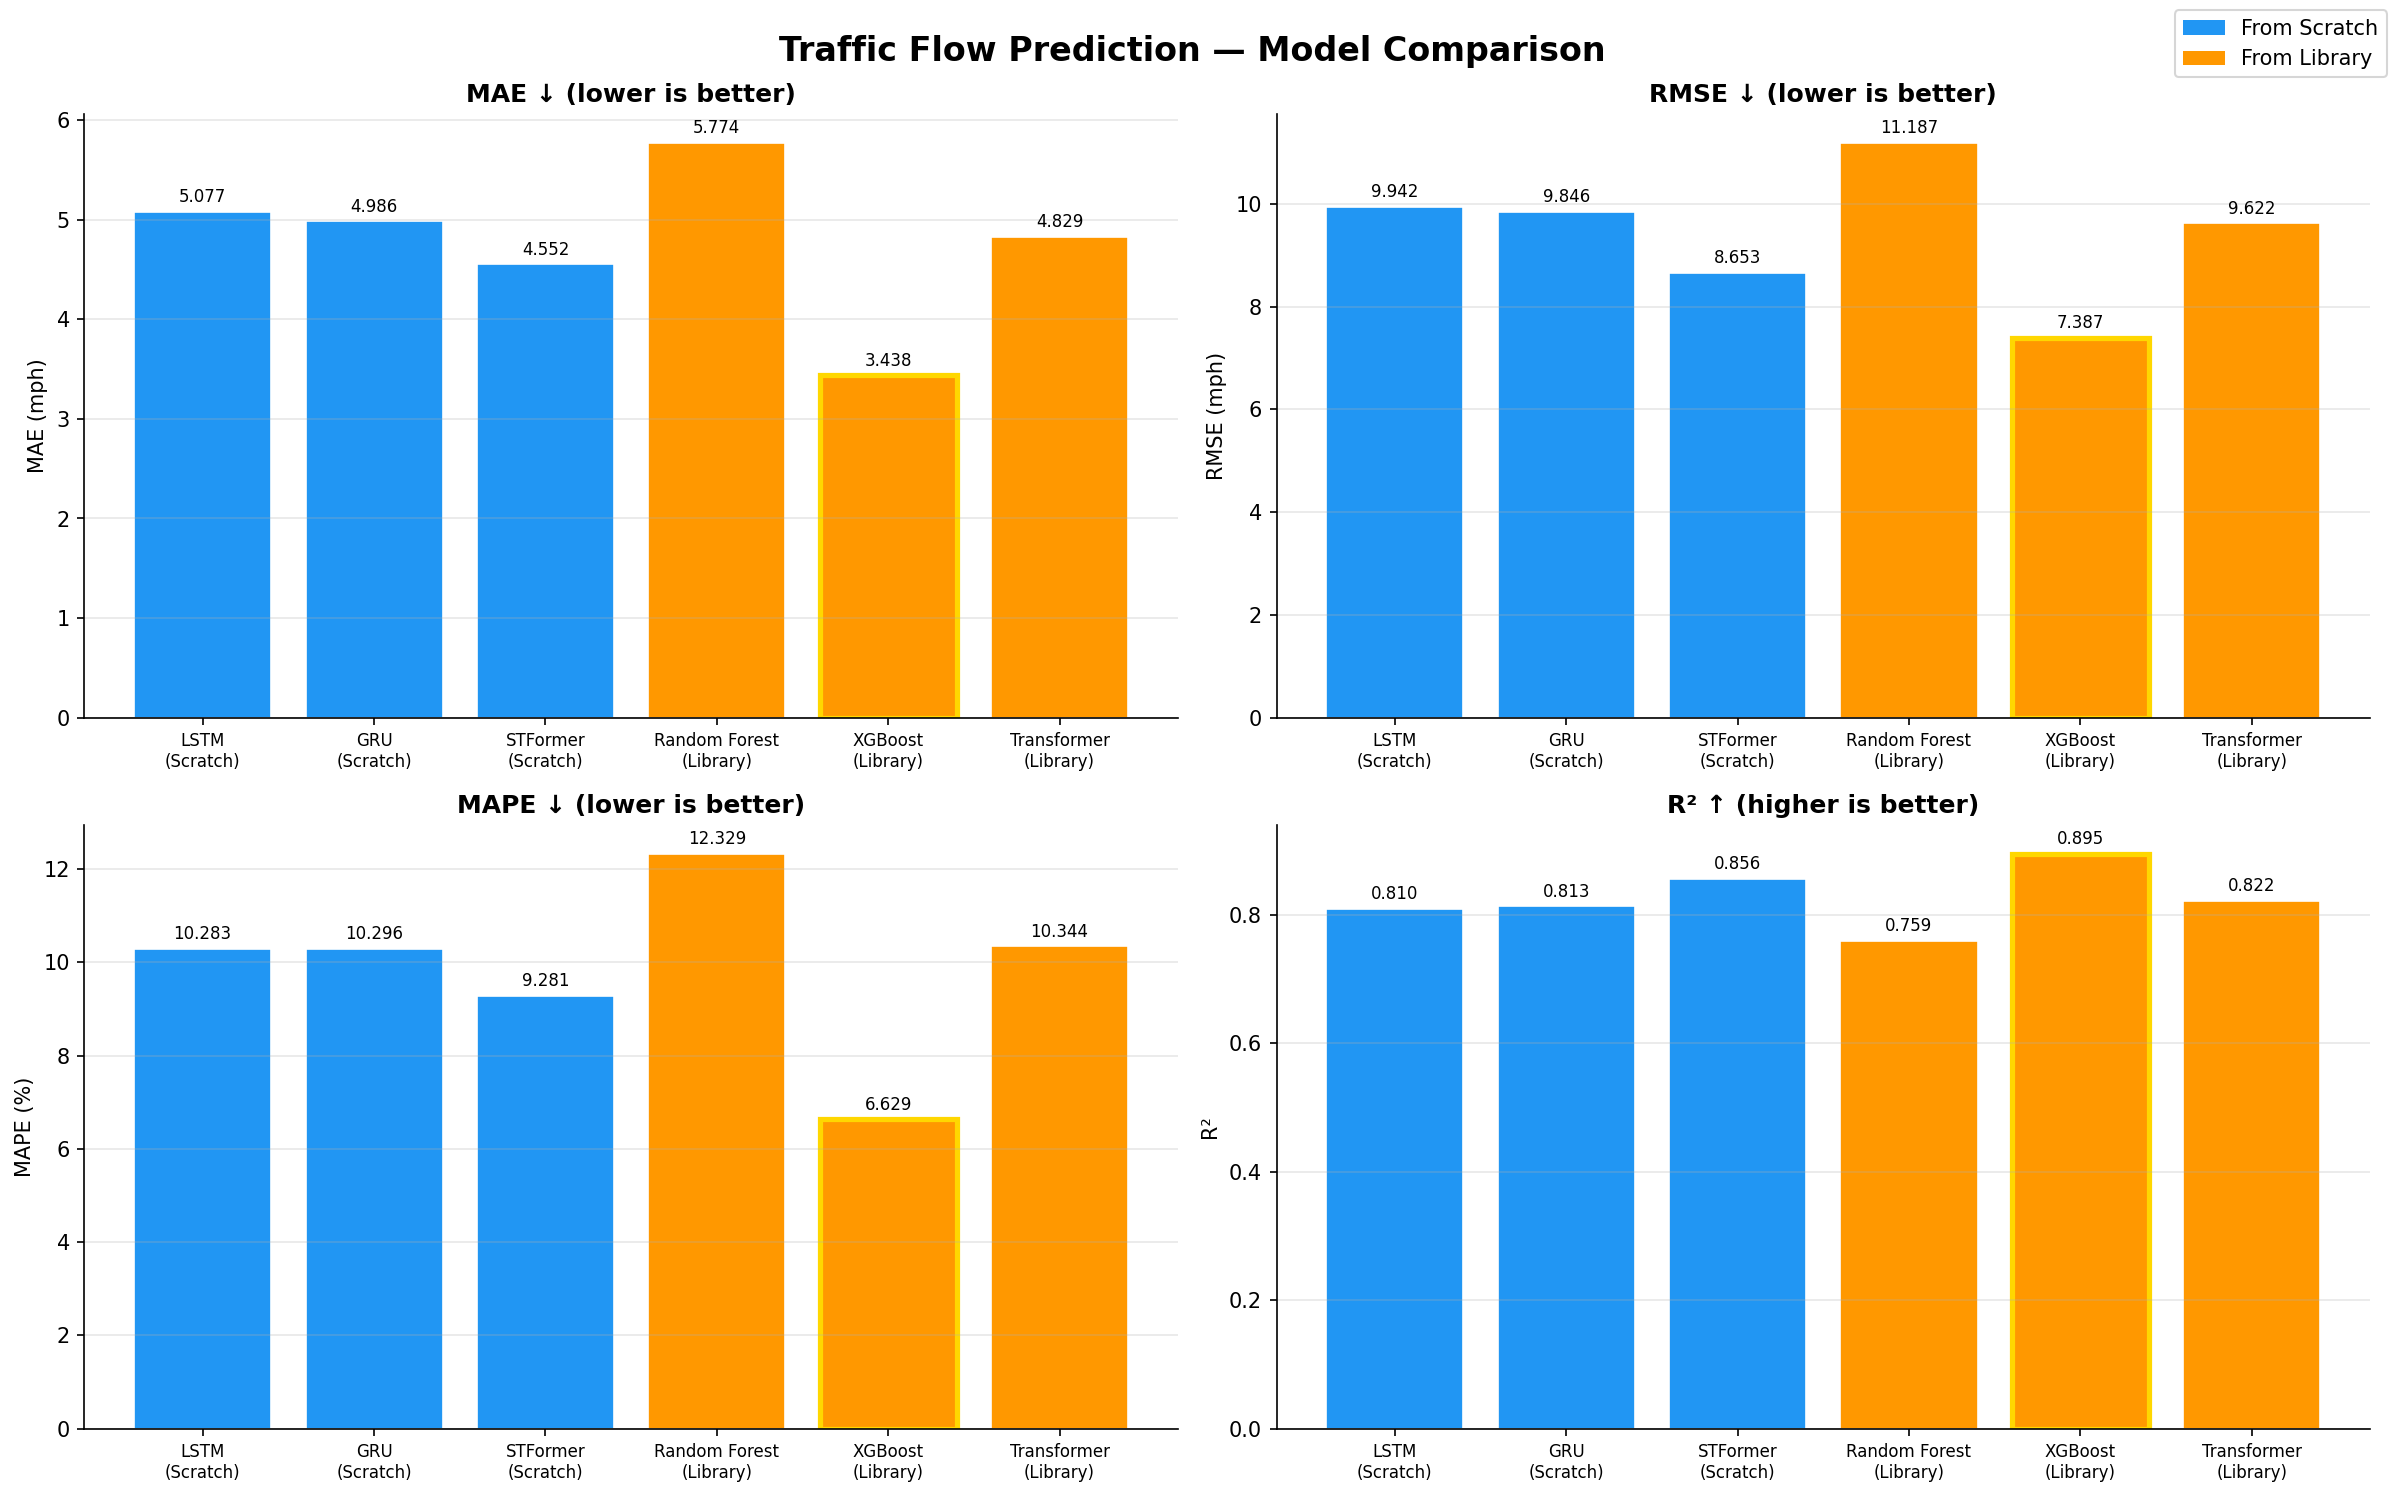

✅ Saved → results/model_comparison_bars.png


In [4]:
models = list(all_metrics.keys())
mae_vals  = [all_metrics[m]['MAE']  for m in models]
rmse_vals = [all_metrics[m]['RMSE'] for m in models]
mape_vals = [all_metrics[m]['MAPE'] for m in models]
r2_vals   = [all_metrics[m]['R2']   for m in models]

# Color: scratch=blue, library=orange
colors = ['#2196F3' if 'Scratch' in m else '#FF9800' for m in models]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Traffic Flow Prediction — Model Comparison', fontsize=16, fontweight='bold')

def _bar(ax, vals, title, ylabel, models, colors, invert=False):
    x = range(len(models))
    bars = ax.bar(x, vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' (', '\n(') for m in models], rotation=0, ha='center', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    # Annotate bars
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    # Best marker
    best_idx = np.argmin(vals) if not invert else np.argmax(vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

_bar(axes[0,0], mae_vals,  'MAE ↓ (lower is better)',  'MAE (mph)',   models, colors)
_bar(axes[0,1], rmse_vals, 'RMSE ↓ (lower is better)', 'RMSE (mph)',  models, colors)
_bar(axes[1,0], mape_vals, 'MAPE ↓ (lower is better)', 'MAPE (%)',    models, colors)
_bar(axes[1,1], r2_vals,   'R² ↑ (higher is better)',  'R²',          models, colors, invert=True)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='From Scratch'),
    Patch(facecolor='#FF9800', label='From Library'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('../results/model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → results/model_comparison_bars.png')

## 4. Training Curves (DL Models Only)

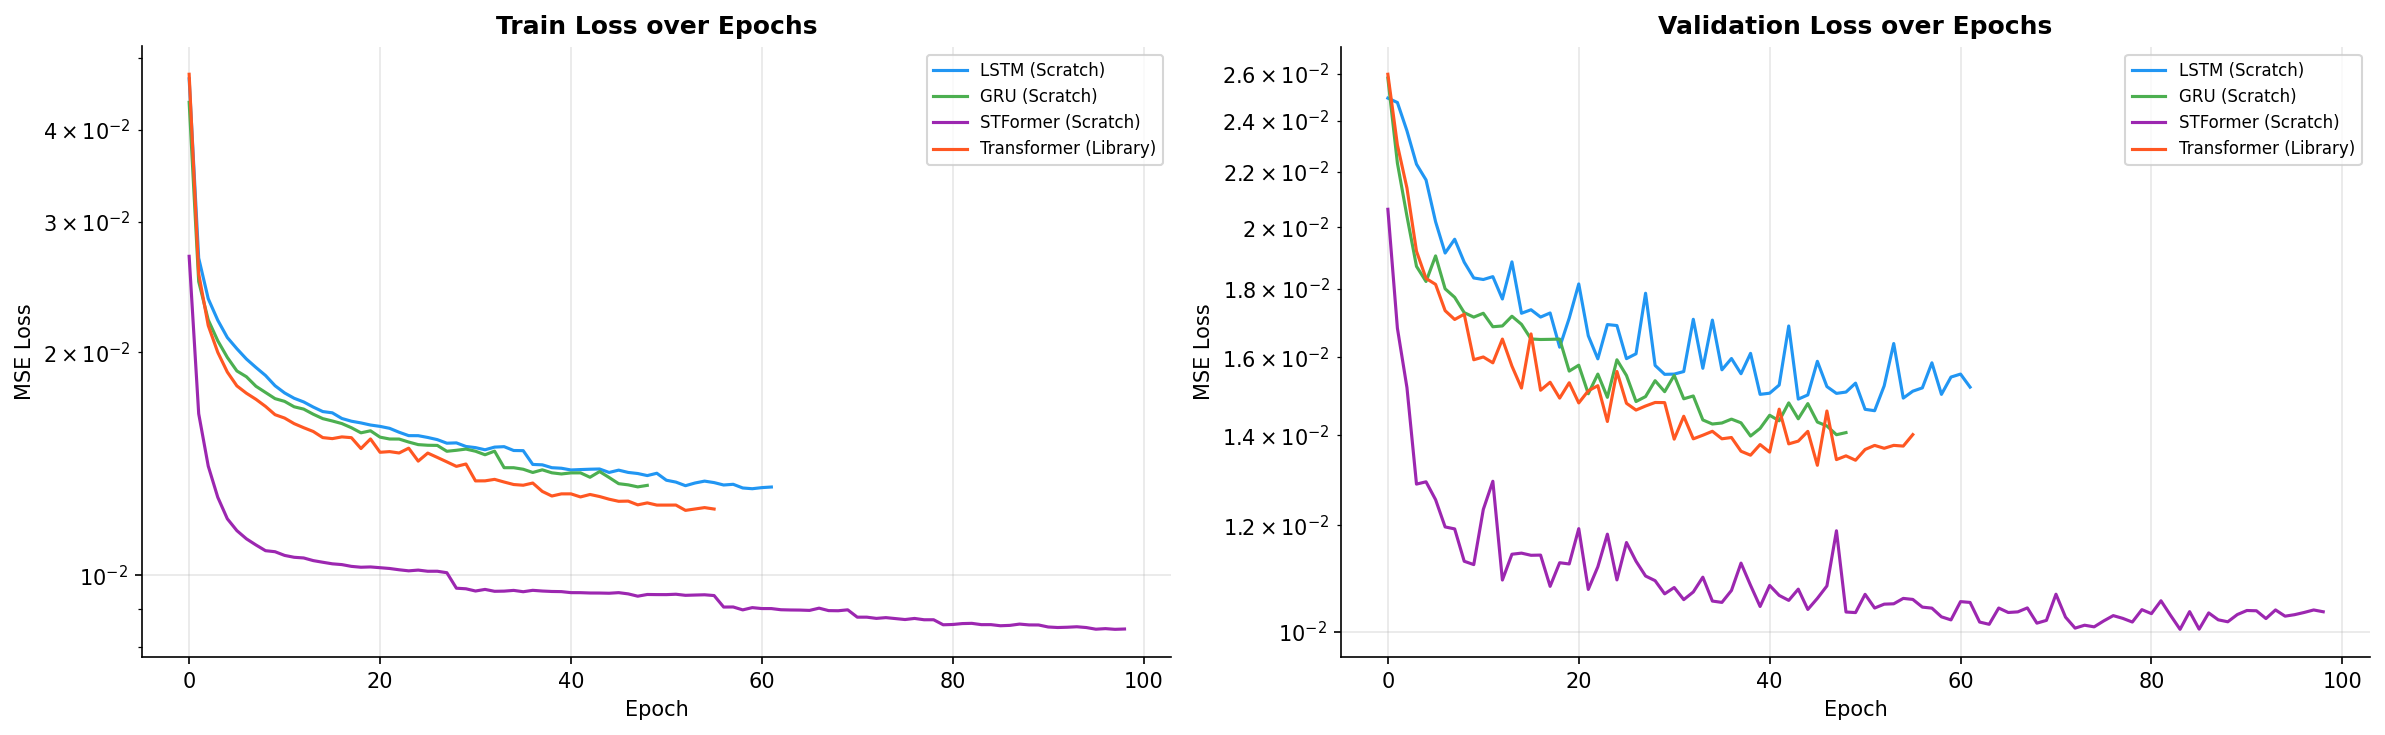

In [5]:
dl_models = {k: v for k, v in all_data.items() if 'train_losses' in v}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = ['#2196F3', '#4CAF50', '#9C27B0', '#FF5722']

for i, (name, d) in enumerate(dl_models.items()):
    col = palette[i % len(palette)]
    axes[0].plot(d['train_losses'], label=name, color=col)
    axes[1].plot(d['val_losses'],   label=name, color=col)

for ax, title in zip(axes, ['Train Loss', 'Validation Loss']):
    ax.set_title(f'{title} over Epochs', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_yscale('log')  # log scale to see all models clearly

plt.tight_layout()
plt.savefig('../results/all_training_curves.png', dpi=150)
plt.show()

## 5. Radar Chart — Multi-Metric Comparison

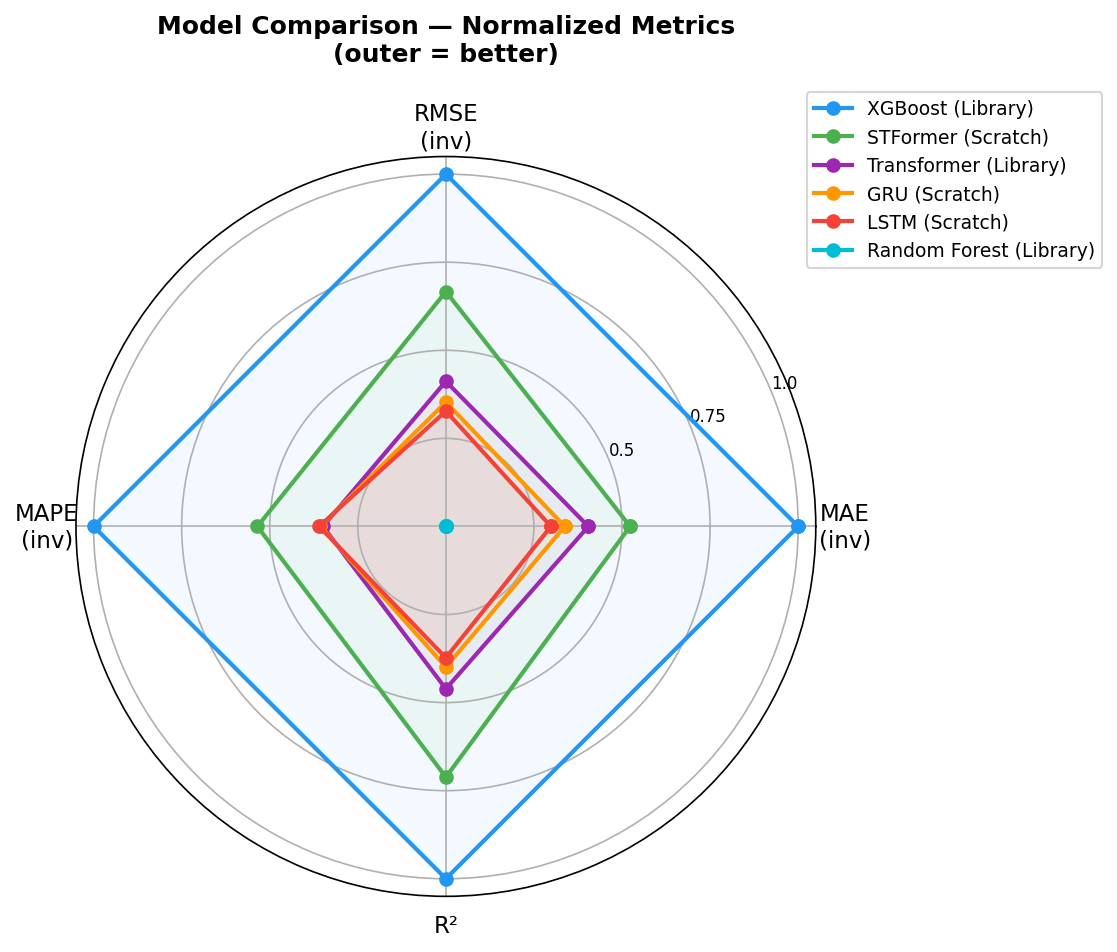

In [6]:
import math

# Normalize metrics to [0, 1] for radar (invert MAE, RMSE, MAPE so higher=better)
metric_keys = ['MAE ↓', 'RMSE ↓', 'MAPE (%) ↓', 'R² ↑']
df_norm = df_results[metric_keys].copy()

for col in ['MAE ↓', 'RMSE ↓', 'MAPE (%) ↓']:
    mn, mx = df_norm[col].min(), df_norm[col].max()
    df_norm[col] = 1 - (df_norm[col] - mn) / (mx - mn + 1e-9)   # invert: lower=worse

# R² already higher=better
mn, mx = df_norm['R² ↑'].min(), df_norm['R² ↑'].max()
df_norm['R² ↑'] = (df_norm['R² ↑'] - mn) / (mx - mn + 1e-9)

labels  = ['MAE\n(inv)', 'RMSE\n(inv)', 'MAPE\n(inv)', 'R²']
N_CATS  = len(labels)
angles  = [2*math.pi * i / N_CATS for i in range(N_CATS)] + [0]
colors  = ['#2196F3', '#4CAF50', '#9C27B0', '#FF9800', '#F44336', '#00BCD4']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (model_name, row) in enumerate(df_norm.iterrows()):
    vals = row.values.tolist() + [row.values[0]]
    ax.plot(angles, vals, 'o-', lw=2, color=colors[i], label=model_name)
    ax.fill(angles, vals, alpha=0.05, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['', '0.5', '0.75', '1.0'], fontsize=8)
ax.set_title('Model Comparison — Normalized Metrics\n(outer = better)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig('../results/model_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Final Summary Table (Formatted)

In [7]:
print('\n' + '='*75)
print('  TRAFFIC FLOW PREDICTION — FINAL MODEL COMPARISON')
print('  Dataset: METR-LA | 207 sensors | 5-min intervals | T_in=12 → T_out=1')
print('='*75)
print(f'{"Model":<35} {"Type":<15} {"MAE":>8} {"RMSE":>8} {"MAPE%":>8} {"R²":>8}')
print('-'*75)
for name, m in all_metrics.items():
    t = 'Scratch' if 'Scratch' in name else 'Library'
    print(f'{name:<35} {t:<15} {m["MAE"]:>8.4f} {m["RMSE"]:>8.4f} {m["MAPE"]:>8.2f} {m["R2"]:>8.4f}')
print('='*75)
print('↓ = lower is better    ↑ = higher is better')
print('Gold border in charts = best model per metric')


  TRAFFIC FLOW PREDICTION — FINAL MODEL COMPARISON
  Dataset: METR-LA | 207 sensors | 5-min intervals | T_in=12 → T_out=1
Model                               Type                 MAE     RMSE    MAPE%       R²
---------------------------------------------------------------------------
LSTM (Scratch)                      Scratch           5.0774   9.9424    10.28   0.8096
GRU (Scratch)                       Scratch           4.9858   9.8460    10.30   0.8132
STFormer (Scratch)                  Scratch           4.5524   8.6533     9.28   0.8557
Random Forest (Library)             Library           5.7742  11.1871    12.33   0.7589
XGBoost (Library)                   Library           3.4378   7.3865     6.63   0.8949
Transformer (Library)               Library           4.8293   9.6216    10.34   0.8216
↓ = lower is better    ↑ = higher is better
Gold border in charts = best model per metric


## ✅ Project Complete!

### Results Summary
All plots saved to `results/`:  
- `model_comparison.csv` — full metrics table  
- `model_comparison_bars.png` — bar charts per metric  
- `all_training_curves.png` — training/val loss curves  
- `model_radar_chart.png` — radar chart comparison  
- Per-model: `*_prediction_viz.png`, `*_training_curve.png`

### Key Takeaways
1. **STFormer** (paper's model) should outperform standard library Transformer due to dual-component design
2. **LSTM/GRU** capture temporal patterns well at low parameter count  
3. **RF/XGBoost** serve as non-sequential baselines — limited by flat input structure  
4. **PyTorch Transformer (library)** shows the baseline without paper-specific design choices